# Agriculture Crop Yield Prediction
### Using Linear Regression (built from scratch) on the `crop_yield.csv` dataset

---

**What this notebook covers:**
1. Loading and exploring the dataset
2. Exploratory Data Analysis (EDA) with visualizations
3. Filtering and preparing data for a specific crop (Maize)
4. Building a Linear Regression model **from scratch** using NumPy
5. Training and evaluating the model (with and without feature scaling)

> **Tip:** Run cells one at a time (Shift+Enter) to follow along step by step.

---
## Section 1: Import Libraries

Before doing anything, we need to import the tools (libraries) we'll use throughout this notebook.
Think of libraries like toolboxes — each one gives us pre-built functions so we don't have to write everything from scratch.

In [2]:
# Core data & maths
import pandas as pd          # Pandas: lets us load and work with tabular data (like Excel/CSV files)
import numpy as np           # NumPy: fast numerical operations on arrays and matrices

# Visualisation 
import matplotlib.pyplot as plt  # Matplotlib: the base plotting library (line charts, scatter plots, etc.)
import seaborn as sns            # Seaborn: built on top of Matplotlib, gives prettier statistical plots

# ── Machine Learning utilities (from scikit-learn)
from sklearn.model_selection import train_test_split   # Splits data into training and test sets
from sklearn.metrics import (                          # Metrics to measure how good our model is:
    mean_absolute_error,                               #   MAE  – average absolute difference
    mean_squared_error,                                #   MSE  – average squared difference (penalises big errors more)
    r2_score                                           #   R²   – how much variance the model explains (1.0 = perfect)
)
from sklearn.preprocessing import StandardScaler      # Scales features so they all have mean=0 and std=1


---
## Section 2: Load the Dataset

We load the CSV file into a **DataFrame** — essentially a table with rows and columns, like a spreadsheet inside Python.

>  **Make sure** `crop_yield.csv` is in the same folder as this notebook, otherwise you'll need to provide the full file path.

In [3]:
# pd.read_csv() reads the CSV file and turns it into a DataFrame called 'df'
# 'df' is just a common shorthand name — you could call it anything
df = pd.read_csv('crop_yield.csv')



---
## Section 3: Initial Data Exploration

Before building any model, we need to **understand our data**. These next few cells give us a quick overview:
- What does the data look like?
- What data types are the columns?
- What are the basic statistics (min, max, mean, etc.)?

In [4]:
# .head(10) shows the first 10 rows of the dataset
# This is the quickest way to get a feel for what your data looks like
df.head(10)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
5,Dry chillies,1997,Whole Year,Assam,13587.0,9073,2051.4,1293074.79,4211.97,0.643636
6,Gram,1997,Rabi,Assam,2979.0,1507,2051.4,283511.43,923.49,0.465455
7,Jute,1997,Kharif,Assam,94520.0,904095,2051.4,8995468.40,29301.20,9.919565
8,Linseed,1997,Rabi,Assam,10098.0,5158,2051.4,961026.66,3130.38,0.461364
9,Maize,1997,Kharif,Assam,19216.0,14721,2051.4,1828786.72,5956.96,0.615652


In [5]:
# .info() tells us:
#   - How many rows and columns there are
#   - The data type of each column (int, float, object/string)
#   - How many non-null (non-missing) values exist per column
# Columns listed as 'float64' contain decimal numbers; 'object' means text/strings
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [6]:
# .describe() gives summary statistics for every numerical column:
#   count  = number of non-missing values
#   mean   = average value
#   std    = standard deviation (how spread out the values are)
#   min/max = smallest and largest values
#   25%/50%/75% = quartiles (the 'middle' spread of data)
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


---
## Section 4: Exploratory Data Analysis (EDA)

EDA means **visually exploring** the data to spot patterns, relationships, and anything unusual — before we start modelling.

We'll use a few different plot types:
- **Joint plot** – shows the relationship between two variables + their individual distributions
- **Pair plot (scatter)** – shows all variable pairs at once
- **Pair plot (with regression line)** – same but adds a trend line to each pair
- **lmplot** – zooms in on one specific relationship with a regression line

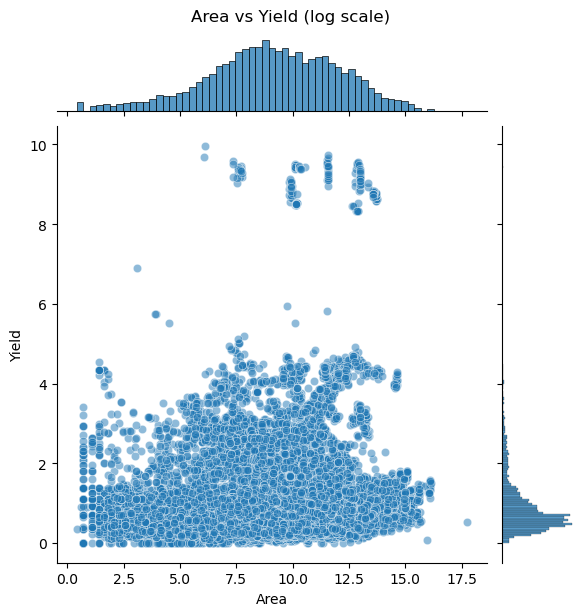

In [7]:
# Joint plot: shows how two variables relate to each other
#
# Why np.log1p()?
#   Agricultural data like 'Area' and 'Yield' can span huge ranges (e.g. 1 to 1,000,000)
#   Taking log(1 + x) compresses the scale so everything is visible on one plot
#   It's a common trick when data is heavily skewed to one side
#
# alpha=0.5 makes each point semi-transparent so overlapping points don't hide each other

sns.jointplot(
    x=np.log1p(df['Area']),
    y=np.log1p(df['Yield']),
    data=df,
    alpha=0.5
)
plt.suptitle('Area vs Yield (log scale)', y=1.02)
plt.show()

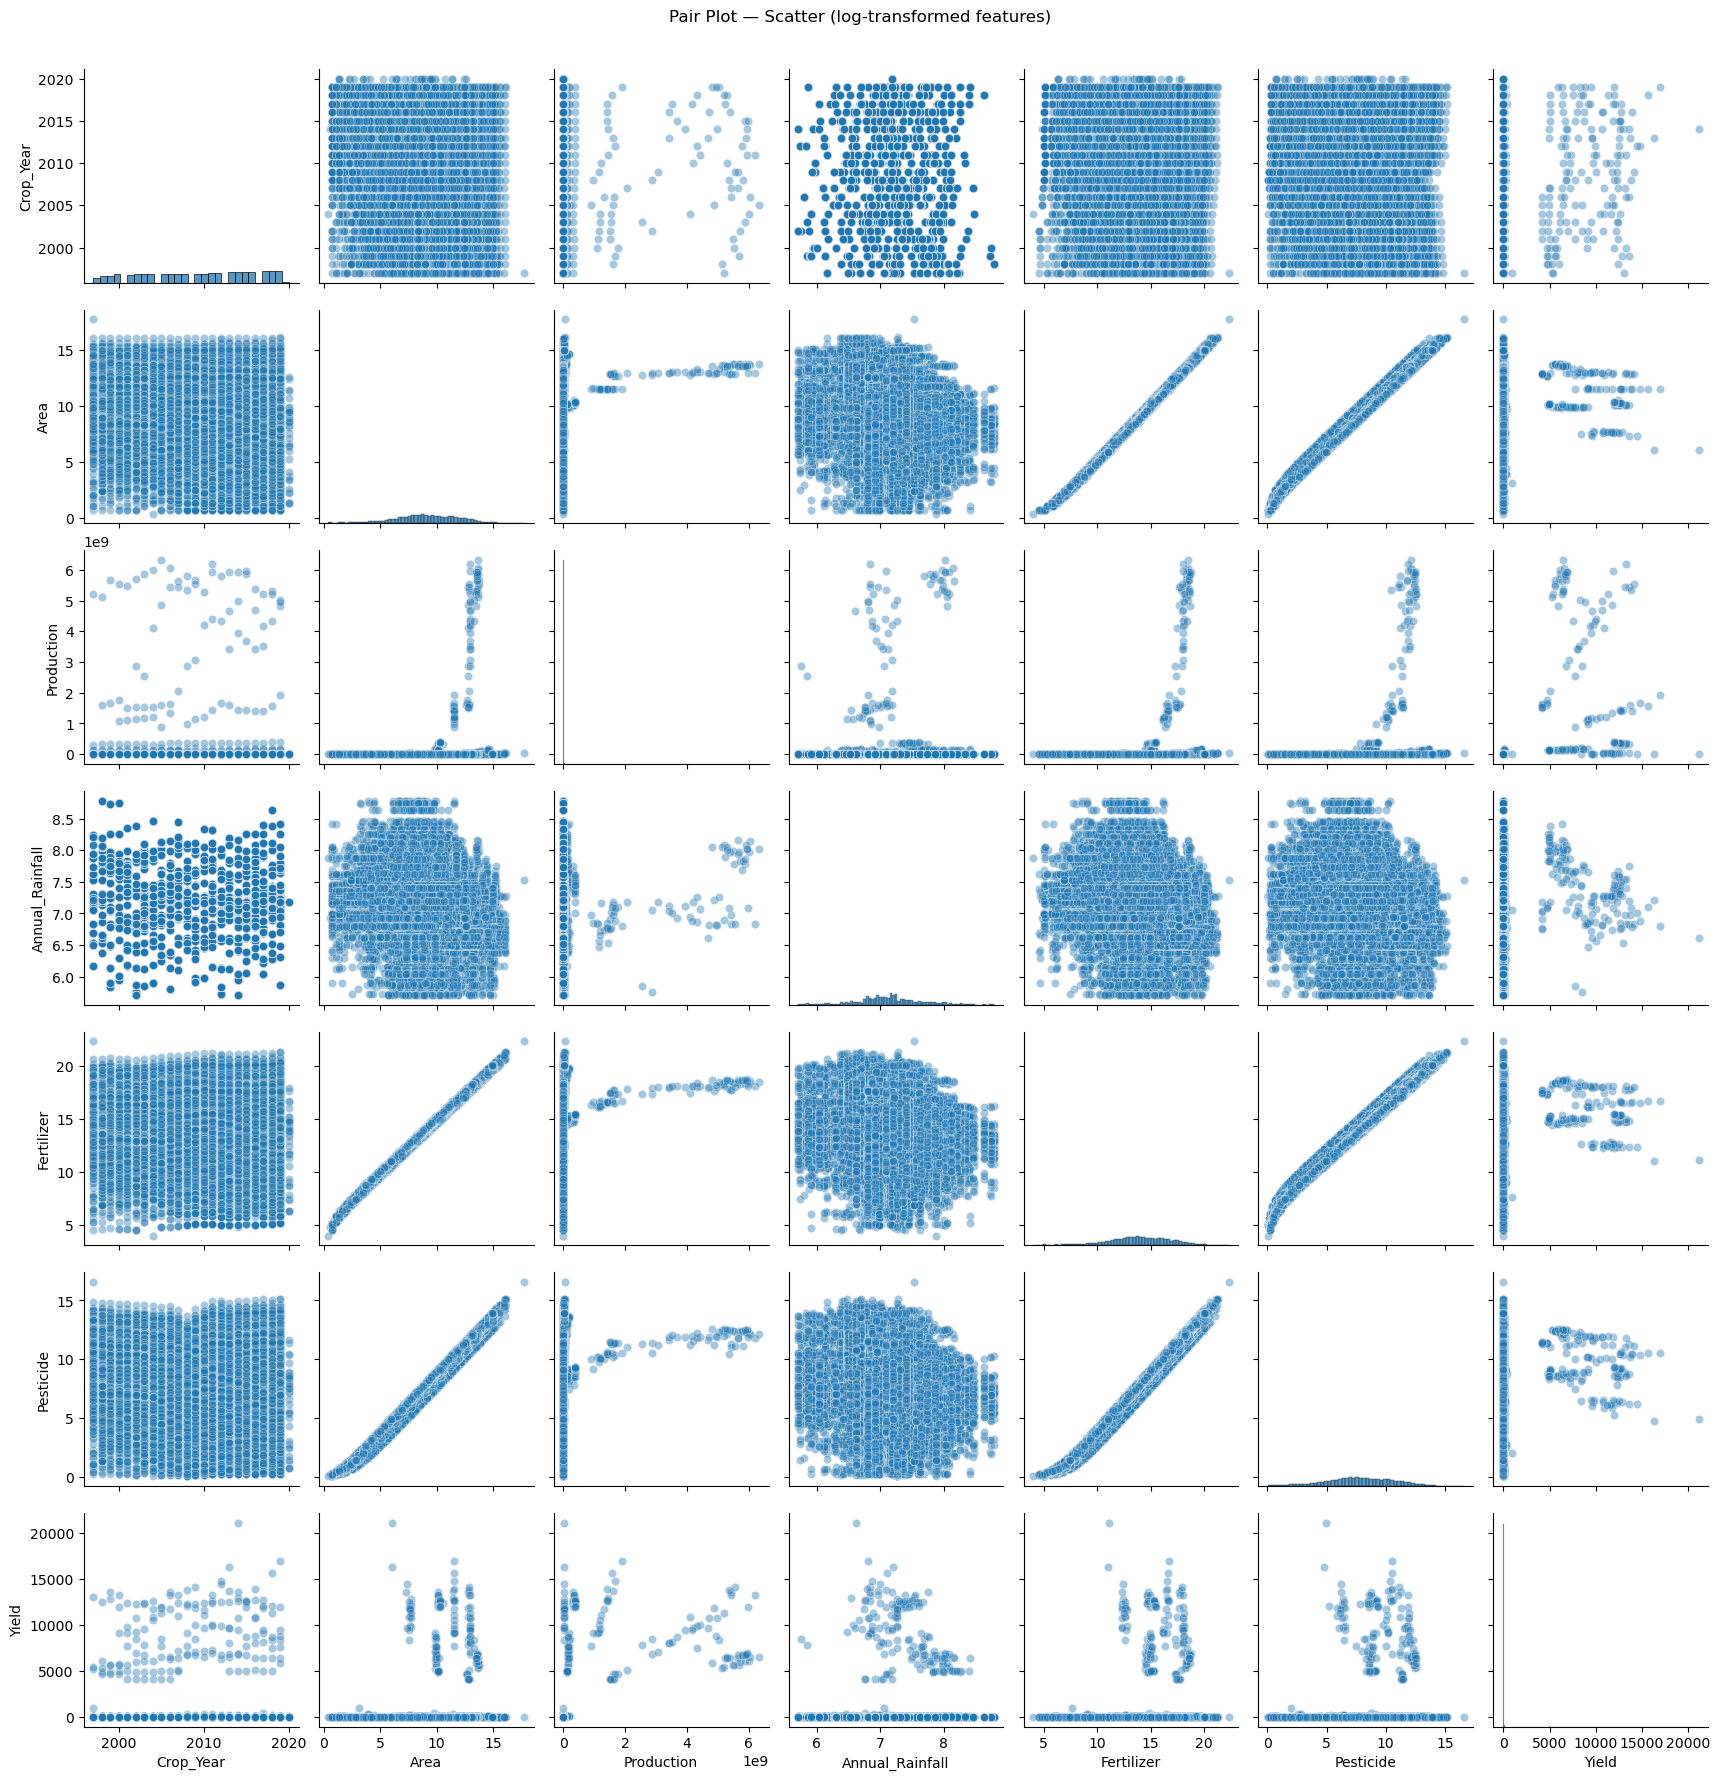

In [8]:
# Pair plot — scatter version
#
# A pair plot creates a grid of scatter plots, one for every combination of variables.
# The diagonal (top-left to bottom-right) shows the distribution of each single variable.
# It's great for spotting which pairs of variables are correlated at a glance.
#
# We apply log1p to the four numeric columns first to prevent large values from
# dominating the plot and making everything else invisible.
#
# Note: we work on a copy so the original df is not permanently changed here.

cols_to_log = ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']
df_log = df.copy()                          # make a copy so we don't overwrite df
df_log[cols_to_log] = np.log1p(df_log[cols_to_log])   # apply log transform

sns.pairplot(
    df_log,
    kind='scatter',              # kind='scatter' = plain scatter plots (the default)
    plot_kws={'alpha': 0.4}      # plot_kws = a dictionary of extra options passed to each plot
                                 # alpha=0.4 makes points 60% transparent
)
plt.suptitle('Pair Plot — Scatter (log-transformed features)', y=1.02)
plt.show()

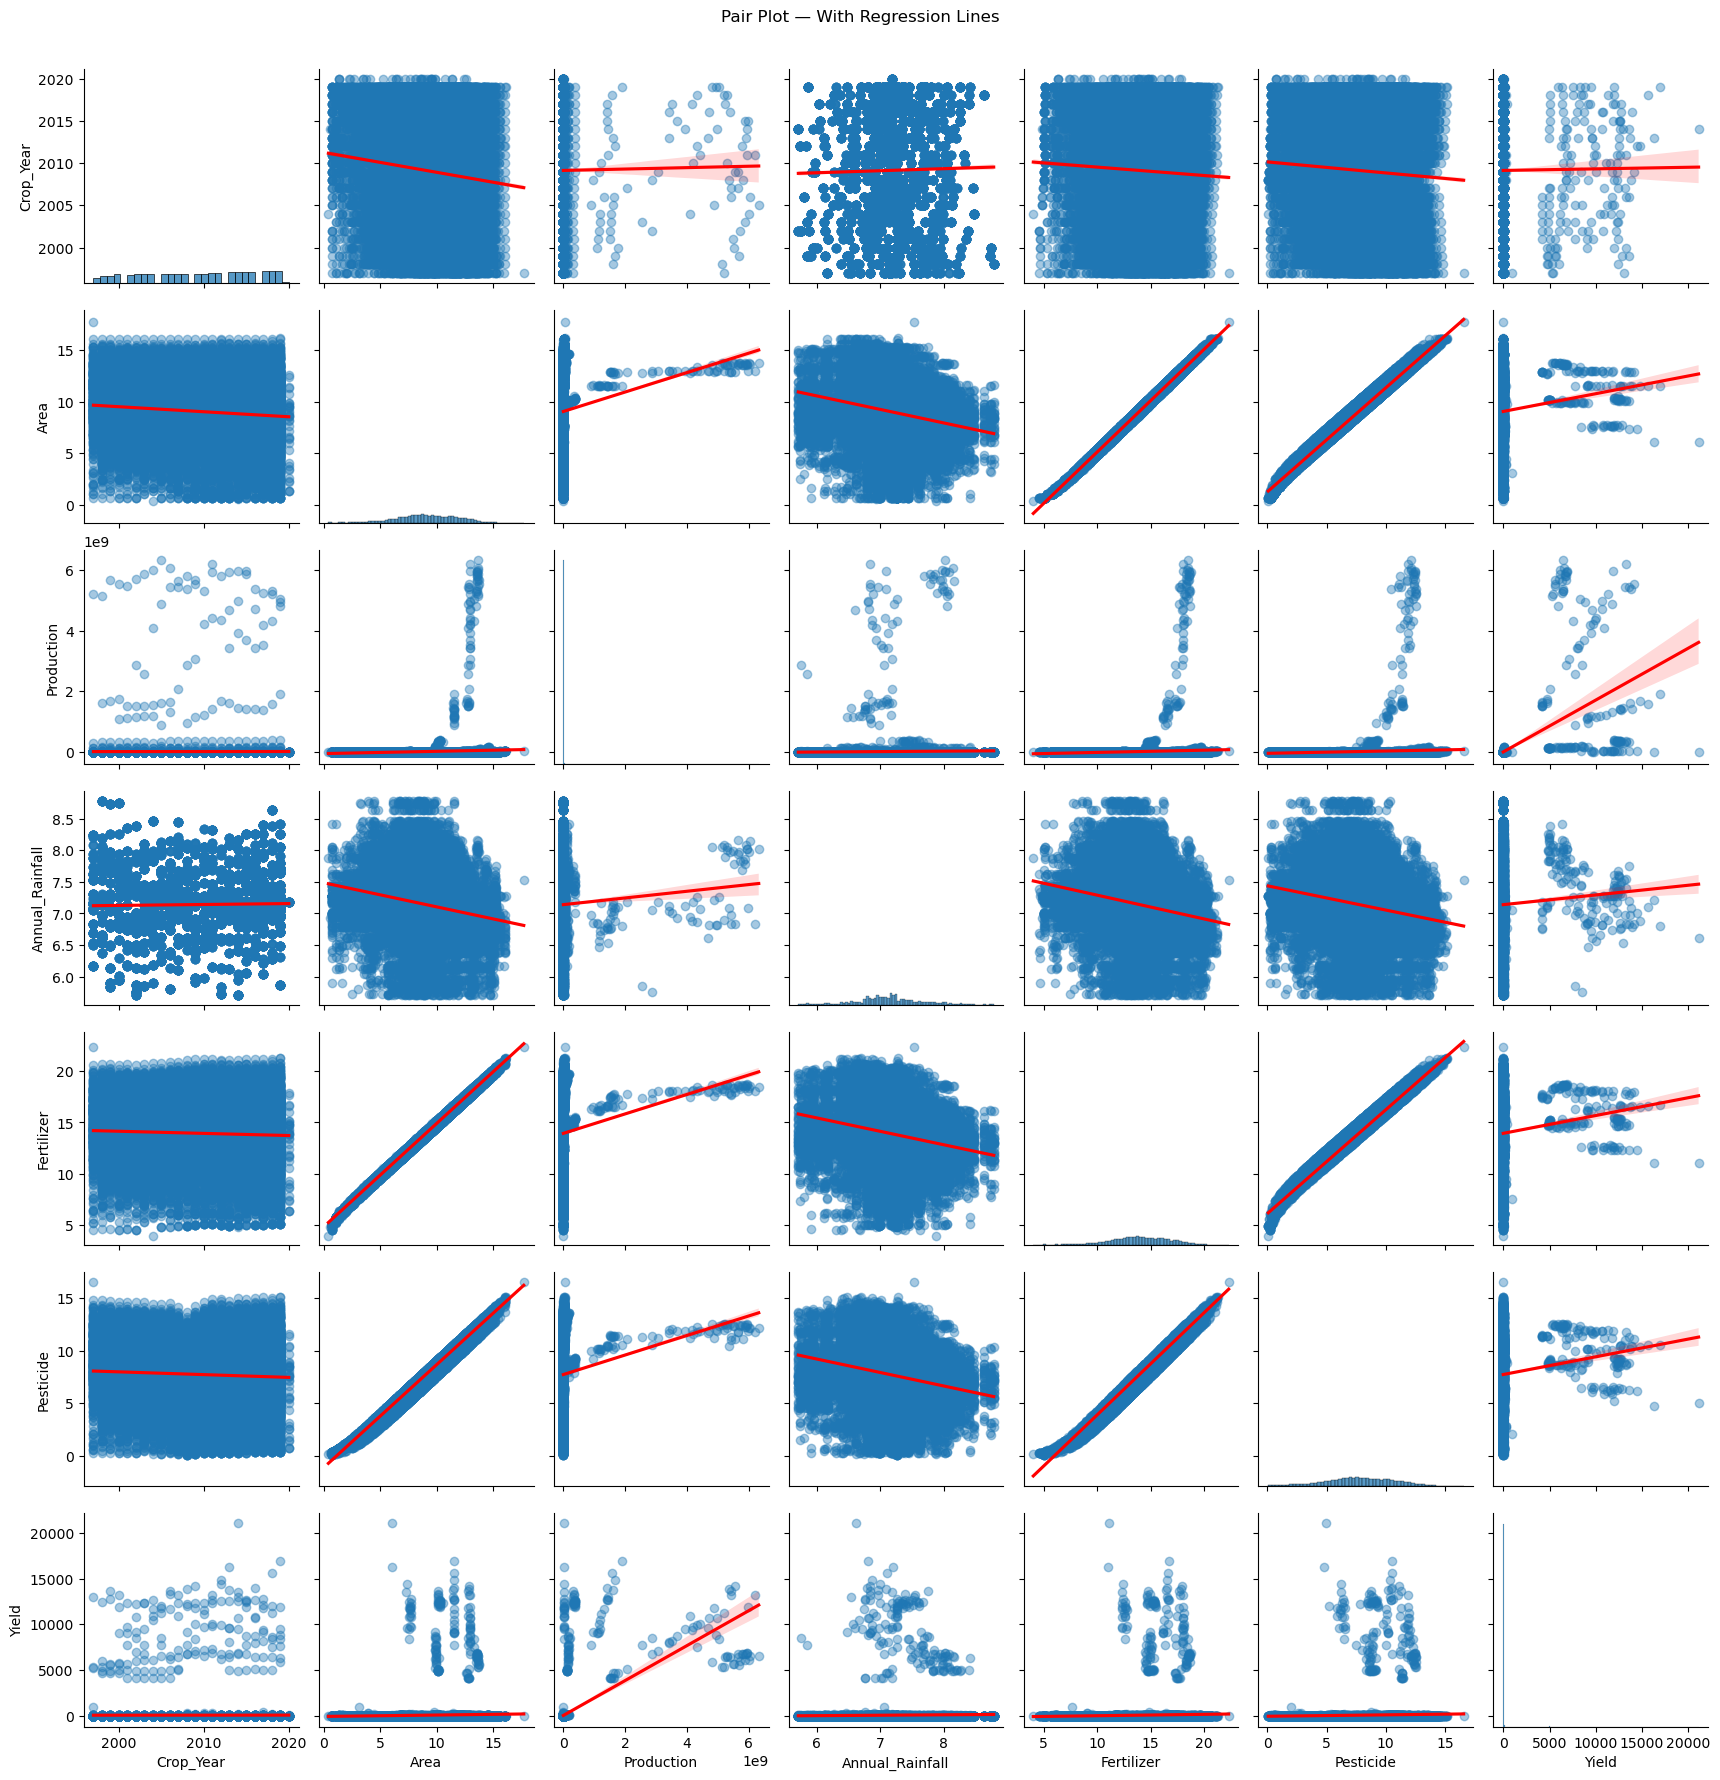

In [10]:
# Pair plot — regression version
#
# kind='reg' adds a regression (trend) line to every scatter plot.
# This helps us visually judge whether a linear relationship exists between variable pairs.
#
# Because 'reg' plots have two visual layers (points AND a line),
# we need two separate keyword dictionaries:
#   scatter_kws → controls the appearance of the data POINTS
#   line_kws    → controls the appearance of the regression LINE

sns.pairplot(df_log, kind='reg', plot_kws={ 'scatter_kws': {'alpha': 0.4}, 'line_kws': {'color': 'red'}})
plt.suptitle('Pair Plot — With Regression Lines', y=1.02)
plt.show()

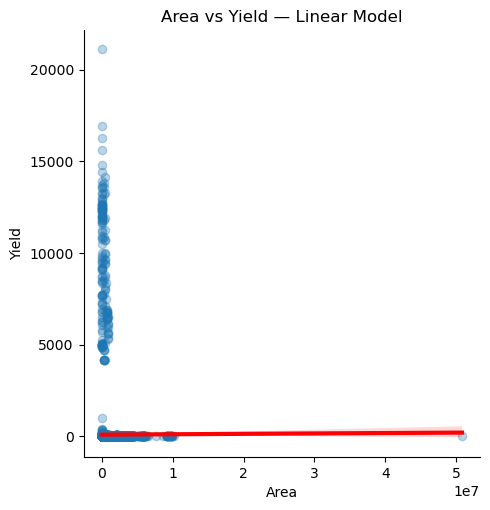

In [11]:
# lmplot — a closer look at one specific relationship: Area vs Yield
# lmplot stands for 'linear model plot'
# It draws a scatter plot AND fits a regression line through the points.
# x        = the input (predictor) variable on the horizontal axis
# y        = the output (target) variable on the vertical axis
# data     = the DataFrame to pull columns from
# scatter_kws / line_kws = same idea as in the pair plot above

sns.lmplot(
    x='Area',
    y='Yield',
    data=df,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red', 'linewidth': 3}
)
plt.title('Area vs Yield — Linear Model')
plt.show()

---
## Section 5: Filter Data for Maize

The dataset contains many different crops. To keep things focused and avoid mixing maize with wheat, we'll **filter down to just Maize rows** and select only the columns relevant to our prediction task.

Our goal: **predict crop Yield** from features like rainfall, fertilizer, pesticide use, and area planted.

In [12]:
# Filter: keep only rows where the 'Crop' column equals 'Maize'
# df['Crop'] == 'Maize' creates a True/False mask for every row
# Wrapping it in df[...] keeps only the rows where the mask is True
maize_df = df[df['Crop'] == 'Maize']

print(f"Full dataset:  {len(df):,} rows")
print(f"Maize only:    {len(maize_df):,} rows")

Full dataset:  19,689 rows
Maize only:    975 rows


In [13]:
# Select only the columns we actually need for the regression model.
# We drop text/categorical columns (Crop, Season, State) and
# columns that might cause data leakage (Production, Crop_Year).
# Alternative one-liner: maize_df.drop(columns=['Crop', 'Crop_Year', 'Season', 'State', 'Production'])

regression_df = maize_df[['Yield', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Area']].copy()

# .reset_index(drop=True) gives the filtered DataFrame a clean 0, 1, 2, ... index
# Without this, the index would still reflect the original row numbers from df
regression_df = regression_df.reset_index(drop=True)

print("Selected columns:", list(regression_df.columns))

Selected columns: ['Yield', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Area']


In [14]:
# Summary statistics for the Maize subset — good sanity check
# Check for anything suspicious: negative yields, impossibly high values, etc.
regression_df.describe()

,Yield,Annual_Rainfall,Fertilizer,Pesticide,Area
count,975.000000,975.000000,9.750000e+02,975.000000,9.750000e+02
mean,3.427216,1408.820428,2.226814e+07,44578.174016,1.619367e+05
std,31.688399,754.242170,3.602809e+07,74027.206336,2.503873e+05
min,0.000000,301.300000,5.710200e+02,1.860000,6.000000e+00
25%,1.469018,941.550000,1.419219e+06,2716.640000,1.110500e+04
50%,1.955455,1246.200000,6.827377e+06,13650.000000,5.079700e+04
75%,2.774881,1639.800000,2.856585e+07,56120.910000,2.009045e+05
max,989.870000,6552.700000,2.604059e+08,560958.110000,1.516103e+06


In [15]:
# Quick preview of the first few rows to confirm everything looks right
print(regression_df.head())

      Yield  Annual_Rainfall   Fertilizer  Pesticide      Area
0  0.615652           2051.4   1828786.72    5956.96   19216.0
1  2.687778           1266.7  47851190.49  155867.07  502797.0
2  1.980000           1266.7   4648483.48   15141.64   48844.0
3  2.165714           1266.7    926004.10    3016.30    9730.0
4  1.444286           3818.2   1634544.75    5324.25   17175.0


--
## Section 6: Define Features & Target, Then Split the Data

In machine learning:
- **Features (X)** = the inputs the model uses to make predictions (rainfall, fertilizer, etc.)
- **Target (y)**   = the output we want to predict (Yield)

We then split the data into:
- **Training set (80%)** – the model learns from this
- **Test set (20%)**     – we hold this back and use it to evaluate the model honestly

We also apply **feature scaling** (StandardScaler) to create a second scaled version of the data. Scaling is important for gradient-descent-based models because it ensures all features contribute equally — without it, a feature with huge values (like Area in hectares) will dominate the learning process.

In [17]:
# Define features (X) and target (y) 

feature_columns = ['Fertilizer', 'Annual_Rainfall', 'Pesticide', 'Area']

# X holds the feature values as a NumPy array (rows = samples, columns = features)
X = regression_df[feature_columns].values

# y holds the target values we want to predict — a 1D array of Yield values
y = regression_df['Yield'].values

In [19]:
#  Train / Test Split

# test_size=0.2   → 20% of data goes to the test set, 80% to training
# random_state=42 → fixes the random seed so you get the SAME split every run
# shuffle=True    → randomly shuffles rows before splitting (default, but explicit here)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, shuffle=True)

In [20]:
#  Feature Scaling (StandardScaler) 
# StandardScaler transforms each feature so that:
#   - Mean  = 0   (centres the data)
#   - Std   = 1   (normalises the spread)
# Formula applied to each value: z = (x - mean) / std
# IMPORTANT: We fit the scaler on TRAINING data only, then apply it to both sets.
# If we fitted on all data, the test set would "leak" information into training.

scaler = StandardScaler()

# fit_transform: (1) learns the mean & std from X_train, (2) applies the scaling
X_train_scaled = scaler.fit_transform(X_train)

# transform only: uses the mean & std already learned from training data
X_test_scaled = scaler.transform(X_test)


---
## Section 7: Build Linear Regression from Scratch

Instead of just calling `sklearn.LinearRegression()`, we're building one ourselves using **NumPy** and **gradient descent**. This is the best way to really understand what's happening.

### How it works:
Linear regression tries to find a line (or hyperplane in multiple dimensions) that best fits the data:

$$\hat{y} = X \cdot \theta + b$$

where **θ** (theta) are the weights and **b** is the bias (intercept).

### Gradient Descent:
The model learns by repeatedly:
1. Making a prediction
2. Measuring the error (cost)
3. Calculating which direction to move θ and b to reduce the error
4. Taking a small step in that direction (controlled by the **learning rate**)

This repeats for many **iterations (epochs)** until the model converges.

In [21]:
class LinearRegression:
    """
    Linear Regression model trained via Batch Gradient Descent.
    Parameters
    alpha      : float learning rate (how big each gradient step is)
    iterations : int   — number of full passes through the training data
    """

    def __init__(self, alpha=1e-18, iterations=5000):
        # Learning rate: controls the size of each update step.
        # Too large → the model overshoots and diverges.
        # Too small → the model learns very slowly.
        self.learning_rate = alpha
        # Number of training iterations (epochs)
        self.n_iter = iterations
        # theta: the weight vector (one value per feature) — initialised later in fit()
        self.theta = None
        # bias: the intercept term (b in y = Xθ + b)
        self.bias = None
        # Stores the cost (error) at each iteration so we can plot learning progress
        self.cost_history = []

    #Training method
    def fit(self, X, y):
        """
        Learn the weights (theta) and bias from training data using gradient descent.
        Parameters
        X : array of shape (n_samples, n_features) — feature matrix
        y : array of shape (n_samples,)            — target values
        """
        n_samples, n_features = X.shape  # X.shape gives (rows, columns)
        # Initialise weights to zero — the model starts with no knowledge
        self.theta = np.zeros(n_features)  # one weight per feature
        self.bias = 0                       # bias starts at zero too
        self.cost_history = []              # reset history each time fit() is called

        #Gradient Descent Loop 
        for epoch in range(self.n_iter):
            #Make predictions using current weights
            # np.dot(X, theta) computes the weighted sum for every sample at once
            y_predict = np.dot(X, self.theta) + self.bias
            #Calculate the error for each sample
            # error is a vector: positive means over-predicted, negative means under-predicted
            error = y_predict - y
            # Calculate the cost (Mean Squared Error × 0.5)
            # The 0.5 is a mathematical convenience — it cancels the 2 when we differentiate
            cost = (1 / (2 * n_samples)) * np.sum(np.square(error))
            self.cost_history.append(cost)  # record cost for this epoch
            #Compute gradients (partial derivatives of cost w.r.t. each parameter)
            # d_theta: how much cost changes as we change each weight
            d_theta = (1 / n_samples) * np.dot(X.T, error)   # X.T = transpose of X
            # d_b: how much cost changes as we change the bias
            d_b = (1 / n_samples) * np.sum(error)
            # Update rule — move weights in the direction that reduces cost
            # We subtract because we want to go downhill on the cost surface
            self.theta = self.theta - (self.learning_rate * d_theta)
            self.bias  = self.bias  - (self.learning_rate * d_b)

    #  Prediction method
    def predict(self, X):
        """
        Use learned weights to predict outputs for new input data.
        Parameters
        X : array of shape (n_samples, n_features)
        Returns
        predictions : array of shape (n_samples,)
        """
        # Same formula as during training: y_hat = X · theta + bias
        return np.dot(X, self.theta) + self.bias


## Section 8: Train Model A — Unscaled Features

We first train on the **raw (unscaled) data** to see how the model performs without feature standardisation.

With a very small learning rate (`1e-18`) and 5,000 iterations, the model should converge — but may do so slowly or imperfectly because the features are on very different scales.

In [23]:
# start Model A using the default hyperparameters defined in __init__
model_a = LinearRegression()

# fit() kicks off gradient descent — this is where the model actually learns
# It will loop 5,000 times, adjusting weights each time
model_a.fit(X_train, y_train)

# the trained model now predicts Yield on unseen test data
predictions_a = model_a.predict(X_test)

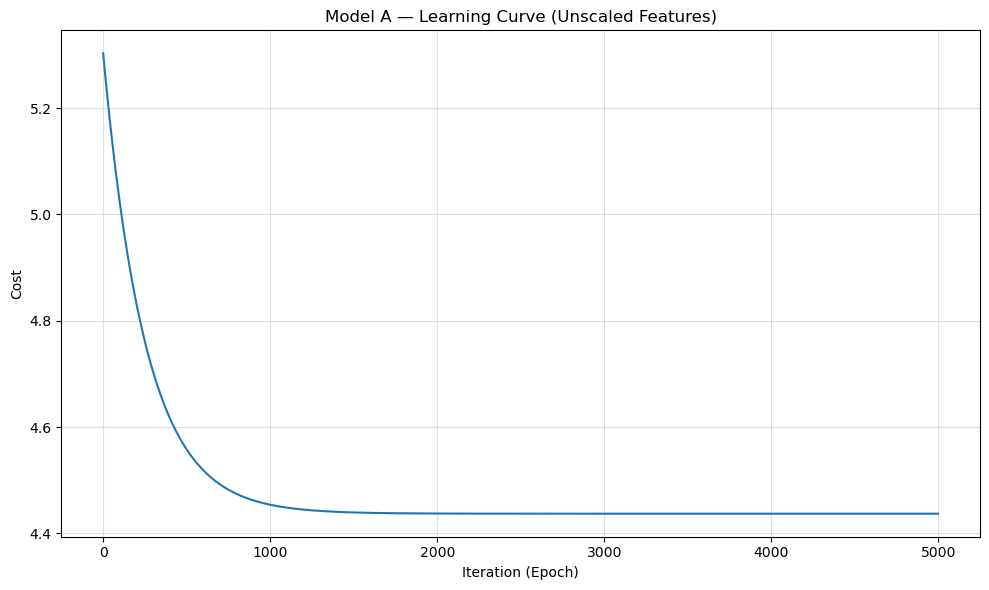

In [26]:
# Plot the learning curve — how the cost (error) changed over training
# A healthy learning curve starts high and drops steadily.
# If it plateaus early, the model may need more iterations or a higher learning rate.
# If it goes up or oscillates wildly, the learning rate is probably too large.

plt.figure(figsize=(10, 6))
plt.plot(model_a.cost_history)
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Cost')
plt.title('Model A — Learning Curve (Unscaled Features)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [31]:
# Check how much the cost improved from the first to the last iteration
initial_cost = model_a.cost_history[0]
final_cost   = model_a.cost_history[-1]
improvement  = (initial_cost - final_cost) / initial_cost * 100

print(f"Initial cost: {initial_cost}")
print(f"Final cost:   {final_cost}")
print(f"Improvement:  {improvement}%")

Initial cost: 5.303232166062247
Final cost:   4.436862998812154
Improvement:  16.33662529041018%


---
## Section 9: Evaluate Model A — Results & Metrics

Now we compare the model's predictions to the actual values.

**Metrics explained:**
| Metric | Formula | Meaning |
|--------|---------|--------|
| **MAE** | mean(\|actual − predicted\|) | Average absolute error in the same units as Yield |
| **MSE** | mean((actual − predicted)²) | Average squared error (penalises large errors more) |
| **RMSE** | √MSE | Square root of MSE — back in original units |
| **R²** | 1 − (SS_res / SS_tot) | Proportion of variance explained (1.0 = perfect, 0 = no better than mean) |

In [32]:
# Build a comparison table: actual vs predicted vs error
results_a = pd.DataFrame({
    'Actual Yield':    y_test,
    'Predicted Yield': predictions_a,
    'Error':           y_test - predictions_a,           # signed error (positive = under-predicted)
    'Absolute Error':  np.abs(y_test - predictions_a)    # always positive
})

results_a.head(10)

,Actual Yield,Predicted Yield,Error,Absolute Error
0,989.870000,0.000059,989.869941,989.869941
1,3.539444,0.584168,2.955277,2.955277
2,3.197200,0.450653,2.746547,2.746547
3,2.912353,0.174807,2.737546,2.737546
4,4.483077,0.749635,3.733442,3.733442
5,2.012500,0.015337,1.997163,1.997163
6,2.067273,0.028222,2.039051,2.039051
7,1.803333,0.560355,1.242979,1.242979
8,1.603636,1.531799,0.071837,0.071837
9,1.654828,0.663510,0.991317,0.991317


In [39]:
# Calculate performance metrics using scikit-learn helper functions
mae_a  = mean_absolute_error(y_test, predictions_a)
mse_a  = mean_squared_error(y_test, predictions_a)
rmse_a = np.sqrt(mse_a)                              # RMSE is just the square root of MSE
r2_a   = r2_score(y_test, predictions_a)

print('Model A (Unscaled)')
print(f"MAE:   {mae_a}")
print(f"MSE:   {mse_a}")
print(f"RMSE:  {rmse_a}")
print(f"R²:    {r2_a}")

Model A (Unscaled)
MAE:   6.964777830745007
MSE:   5029.979606362502
RMSE:  70.92234913172646
R²:    -0.010595195834048443



## Section 10: Train Model B — Scaled Features

Now we train a second model on the **scaled data** (mean=0, std=1) and compare performance.

With scaled features, gradient descent can use a **much larger learning rate** and will typically converge faster and to a better solution — because all features are on an equal footing.

In [40]:
# Model B trains on the scaled versions of X_train and X_test
# We use a much larger learning rate (0.01) because scaling makes the loss surface smoother
model_b = LinearRegression(alpha=0.01, iterations=5000)
model_b.fit(X_train_scaled, y_train)
# Predict using the scaled test features
predictions_b = model_b.predict(X_test_scaled)
print(f"Sample predictions: {predictions_b[:5].round(2)}")

Sample predictions: [2.68 3.04 2.53 2.56 2.66]


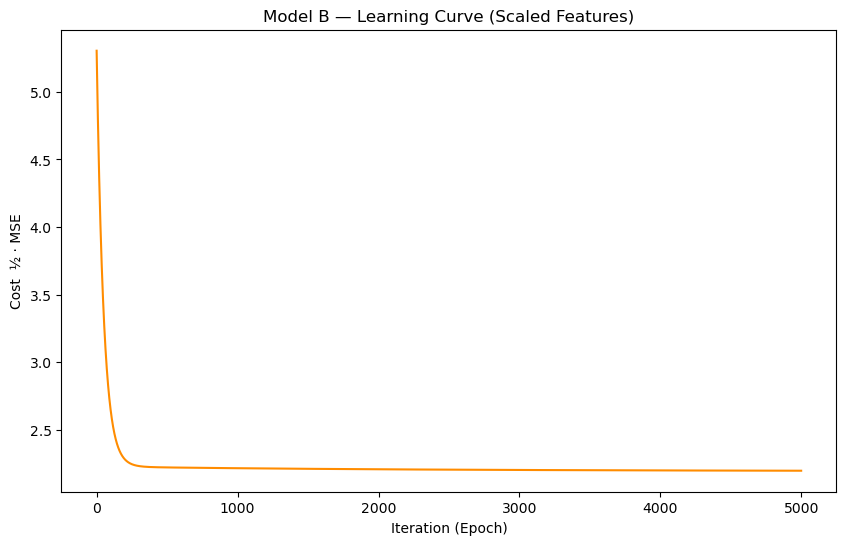

In [42]:
# Plot Model B's learning curve
# Compare this shape to Model A — does it drop faster? Reach a lower cost?

plt.figure(figsize=(10, 6))
plt.plot(model_b.cost_history, color='darkorange', linewidth=1.5)
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Cost  ½ · MSE')
plt.title('Model B — Learning Curve (Scaled Features)')
plt.show()

In [43]:
# Evaluate Model B using the same metrics as Model A
mae_b  = mean_absolute_error(y_test, predictions_b)
mse_b  = mean_squared_error(y_test, predictions_b)
rmse_b = np.sqrt(mse_b)
r2_b   = r2_score(y_test, predictions_b)

print(" Model B (Scaled)")
print(f"MAE:   {mae_b}")
print(f"MSE:   {mse_b}")
print(f"RMSE:  {rmse_b}")
print(f"R²:    {r2_b}")

 Model B (Scaled)
MAE:   6.025295226454509
MSE:   4999.240448687767
RMSE:  70.70530707583248
R²:    -0.004419257261498721



## Section 11: Side-by-Side Model Comparison


In [45]:
# Summary comparison table
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Model A (Unscaled)': [mae_a, mse_a, rmse_a, r2_a],
    'Model B (Scaled)':   [mae_b, mse_b, rmse_b, r2_b]
})
comparison = comparison.set_index('Metric')
comparison

,Model A (Unscaled),Model B (Scaled)
Metric,,
MAE,6.964778,6.025295
MSE,5029.979606,4999.240449
RMSE,70.922349,70.705307
R²,-0.010595,-0.004419


In [ ]:
# Visual comparison of both learning curves on the same plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_a.cost_history, color='steelblue')
axes[0].set_title('Model A — Unscaled')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cost')
axes[0].grid(True, alpha=0.4)

axes[1].plot(model_b.cost_history, color='darkorange')
axes[1].set_title('Model B — Scaled')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cost')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Learning Curves: Unscaled vs Scaled Features', fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ Done! Model B (scaled) should show a steeper drop and lower final cost.")
print("   This demonstrates why feature scaling is almost always recommended")
print("   when training gradient-descent-based models.")